In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%gui qt

In [3]:
from pylab import *

In [4]:
from pathlib import Path
import sys

repo = Path.cwd()
if not (repo / "pyLCOS.py").exists():
    repo = repo.parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import pyLCOS

In [5]:
from utilities.displays import display_discovery

In [6]:
display_discovery()

{0: {'name': 'Odyssey G93SD', 'width': 5120, 'height': 1440, 'x': 0, 'y': 0},
 1: {'name': '\\\\.\\DISPLAY2',
  'width': 1920,
  'height': 1152,
  'x': 5120,
  'y': 0}}

In [7]:
slm = pyLCOS.LCOS(screen = 'meadowlark')



Target slm "meadowlark" found with resolution 1920x1152
Display size (Y,X):  1152 1920


# Manual Hologram Writting

In [8]:
slm.LCOS_Clean()

In [9]:
LCOS_array = zeros((slm.height(), slm.width()), dtype = float64)

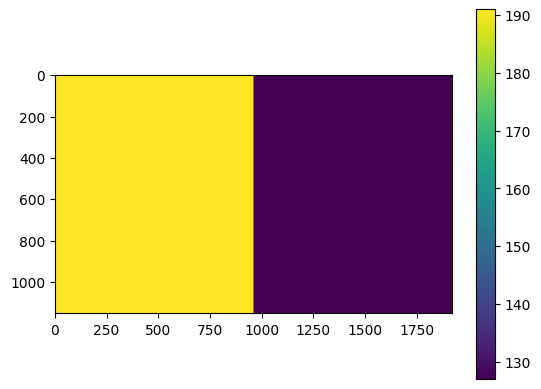

In [10]:
LCOS_array[:, 0:slm.width()//2] = pi/2

LCOS_array_phase_to_level = slm.phaseTolevel(LCOS_array)
imshow(LCOS_array_phase_to_level),colorbar()
slm.LCOS_Display(LCOS_array_phase_to_level, ch=0)

# Interactive half-panel phase (H left / V right)

Sliders set uniform phase from \(-\pi\) to \(+\pi\) on each half. **Piston** checkboxes cycle \(-\pi \leftrightarrow +\pi\) every 250 ms on that half. Phase → `phaseTolevel` → `LCOS_Display`. Preview below.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import threading
import time

_h, _w = slm.LCOSsize
_half = _w // 2
_PISTON_INTERVAL_S = 0.25
_PISTON_STEP = 0.2

_piston = {
    "h": {"run": False, "direction": 1, "thread": None},
    "v": {"run": False, "direction": 1, "thread": None},
}
_last_phase = np.zeros(slm.LCOSsize, dtype=np.float64)
_mask_out = widgets.Output()


def _build_phase_mask():
    phase = np.zeros(slm.LCOSsize, dtype=np.float64)
    phase[:, :_half] = slider_h.value
    phase[:, _half:] = slider_v.value
    return phase


def _any_piston_running():
    return _piston["h"]["run"] or _piston["v"]["run"]


def _update_mask_plot(phase, level):
    with _mask_out:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        im0 = axes[0].imshow(phase, vmin=-pi, vmax=pi, cmap="twilight", aspect="auto")
        axes[0].set_title("Phase (LCOS array)")
        axes[0].axvline(_half - 0.5, color="w", ls="--", lw=0.8)
        fig.colorbar(im0, ax=axes[0], fraction=0.046)
        im1 = axes[1].imshow(level, vmin=0, vmax=255, cmap="gray", aspect="auto")
        axes[1].set_title("Level mask")
        axes[1].axvline(_half - 0.5, color="r", ls="--", lw=0.8)
        fig.colorbar(im1, ax=axes[1], fraction=0.046)
        fig.tight_layout()
        display(fig)
        plt.close(fig)


def _update_half_panel_phase(change=None):
    global _last_phase
    phase = _build_phase_mask()
    _last_phase = phase
    level = slm.phaseTolevel(phase)
    slm.LCOS_Display(level)
    if not _any_piston_running():
        _update_mask_plot(phase, level)


def _piston_loop(side):
    slider = slider_h if side == "h" else slider_v
    state = _piston[side]
    while state["run"]:
        value = slider.value + state["direction"] * _PISTON_STEP
        if value >= pi:
            value = pi
            state["direction"] = -1
        elif value <= -pi:
            value = -pi
            state["direction"] = 1
        slider.value = value
        time.sleep(_PISTON_INTERVAL_S)


def _on_piston_toggle(side, change):
    state = _piston[side]
    if change["new"]:
        state["run"] = True
        t = state["thread"]
        if t is None or not t.is_alive():
            t = threading.Thread(target=_piston_loop, args=(side,), daemon=True)
            state["thread"] = t
            t.start()
    else:
        state["run"] = False
        if not _any_piston_running():
            _update_mask_plot(_last_phase, slm.phaseTolevel(_last_phase))


slider_h = widgets.FloatSlider(
    value=0.0,
    min=-pi,
    max=pi,
    step=0.01,
    description="H (left)",
    continuous_update=True,
    readout_format=".2f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="360px"),
)
slider_v = widgets.FloatSlider(
    value=0.0,
    min=-pi,
    max=pi,
    step=0.01,
    description="V (right)",
    continuous_update=True,
    readout_format=".2f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="360px"),
)
piston_h = widgets.Checkbox(value=False, description="Piston", indent=False)
piston_v = widgets.Checkbox(value=False, description="Piston", indent=False)

slider_h.observe(_update_half_panel_phase, names="value")
slider_v.observe(_update_half_panel_phase, names="value")
piston_h.observe(lambda change: _on_piston_toggle("h", change), names="value")
piston_v.observe(lambda change: _on_piston_toggle("v", change), names="value")

row_h = widgets.HBox([slider_h, piston_h])
row_v = widgets.HBox([slider_v, piston_v])

display(widgets.VBox([row_h, row_v, _mask_out]))
_update_half_panel_phase()

# Simple Holography Gui

In [8]:
from ui.simpleholography.pistoning import PistoningWidget

pistoning_gui = PistoningWidget(slm)
pistoning_gui.show()

# From old

In [11]:
import pyLCOS

In [12]:
import sys
win_home_module_path = r'C:\\LAB\\Coding\\Python\\MODULES'
sys.path.insert(1, win_home_module_path)
import mark_lib as mkl
import holography as holo
t = mkl.times

ModuleNotFoundError: No module named 'mark_lib'

In [6]:
slm = pyLCOS.LCOS(screen=1)

Display size (Y,X):  1440 5120


ValueError: could not broadcast input array from shape (800,800) into shape (561,2560)

### IMPORT ZERNIKES MODULE AND CREATE THEM FROM MODELAB

In [9]:
z = holo.Zernikes(max_zernike_radial_number=6, mask_size_x_in_pixels=960, mask_size_y_in_pixels=960)

NameError: name 'holo' is not defined

In [6]:
print(z.h_mask_center_x, z.h_mask_center_y, z.v_mask_center_x, z.v_mask_center_y)

586 537 1398 535


### SOME MODES MASKS

In [15]:
import h5py
import hdf5storage
path_to_modes = "C:\LAB\Coding\Python\Data\SLM_MASKS\MODELIBRARY_Fibre_GradedIndex_ARCoated_17_1300nm_25mm_lens_SMFside_w0slm_1.93mm_8mm_lens_MMFside_core_diameter_62.5um_maxMG_22_mfd_12.2um_Crosstalk_25dB_OPTI_v3.mat"
data = hdf5storage.loadmat(path_to_modes) # it loads data as a dictionary
data.keys()
modesMasks = angle(data['ILLUMINATION'][:,1024//2-480:1024//2+480,1024//2-480:1024//2+480,])
modesMasks.shape

(253, 960, 960)

### CREATE LCOS OBJECT (PASSING ZERNIKES)

In [8]:
slm = pyLCOS.LCOS(screen=1, mask_size=(960,960), zernikeH = angle(z.field_h), zernikeV = angle(z.field_v)) #Zernike provided as a complex field

Display size (Y,X):  1152 1920


In [9]:
slm.screen

<function LCOS.screen>

In [9]:
t.tic()
Hcenter = [586,537]
Vcenter = [1398,535]
slm.setCenters(Hcenter,Vcenter)
t.toc()

Elapsed time =  0.05190873146057129


0.05190873146057129

In [10]:
slm.setCenters(Hcenter,Vcenter)
t.toc()

Elapsed time =  2.845201253890991


2.845201253890991

### BUNCH OF MASK SETTING AND SETTING DISPLAY MASK

In [23]:
slm.mask_specs['H']['att_enabled'] = 0
slm.mask_specs['H']['attWeight'] = 0
slm.mask_specs['V']['att_enabled'] = 0
slm.mask_specs['V']['attWeight'] = 0
slm.mask_specs['H']['pattern'] = modesMasks[0]
slm.mask_specs['V']['pattern'] = modesMasks[2]

slm.patternEnabled = 1
slm.zernikesEnabled = 1

slm.setmask(pol = 'H')
slm.refreshfreq #check refreshrate.

13.36919443213729

## OTHER STUFF (DEBUGGING)

In [33]:
for i in range(6):
    #t.tic()
    slm.mask_specs['H']['pattern'] = modesMasks[i]
    slm.mask_specs['V']['pattern'] = modesMasks[5-i]
    slm.setmask(pol = 'HV')
    #t.toc()
    

In [10]:
slm.mask_specs['V']['centers'] = [1397,535]

In [ ]:
slm.offset_center = 0
slm._defineCenters()
slm._calcApertures()
slm.setmask(pol = 'V')
print(slm.Hcenter, slm.Vcenter)


[586, 614] [1397, 616]


In [112]:
def binarycheckboard(width, height, spatial_frequency, scale=1, offset = False ,pol = 'HV'):
    y = np.arange(height, dtype = np.float64)#linspace(0,2*pi,1080)
    x = np.arange(width, dtype = np.float64)
    X,Y = np.meshgrid(x,y)
    
    GY = (((Y*spatial_frequency)%(1.0)>=.5)*scale).astype(np.float64)
    GX = (((X*spatial_frequency)%(1.0)>=.5)*scale).astype(np.float64)
     
    chBoard = abs(GX - GY)
    
    if offset == True:
        offset = scale/2
        chBoard -= offset
    
    if pol == 'H':
        chBoard[:,int(x.max()//2):-1] = 0
    elif pol == 'V':
        chBoard[:,0:int(x.max()//2)] = 0

    return(chBoard,GX,GY)

In [113]:
checker, GX, GY = binarycheckboard(960, 960, spatial_frequency = 1/100, scale=1, offset = True, pol = 'HV')

(<matplotlib.image.AxesImage at 0x23acb6064c8>,
 <matplotlib.colorbar.Colorbar at 0x23acb606088>)

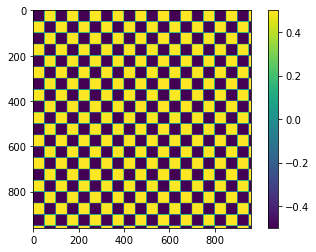

In [114]:
imshow(checker), colorbar()

(<matplotlib.image.AxesImage at 0x23acb517608>,
 <matplotlib.colorbar.Colorbar at 0x23acb469488>)

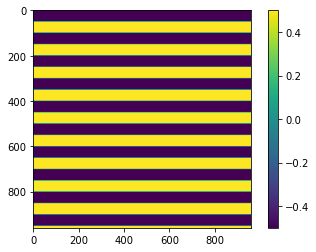

In [111]:
imshow(GY),colorbar()

In [106]:
GY

array([[-0.5, -0.5, -0.5, ..., -0.5, -0.5, -0.5],
       [-0.5, -0.5, -0.5, ..., -0.5, -0.5, -0.5],
       [-0.5, -0.5, -0.5, ..., -0.5, -0.5, -0.5],
       ...,
       [ 0.5,  0.5,  0.5, ...,  0.5,  0.5,  0.5],
       [ 0.5,  0.5,  0.5, ...,  0.5,  0.5,  0.5],
       [ 0.5,  0.5,  0.5, ...,  0.5,  0.5,  0.5]])